### **Mount Drive and Start Spark**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Model_Evaluation") \
    .getOrCreate()

Mounted at /content/drive


### **Load Test Data**

In [2]:
test = spark.read.parquet(
"/content/drive/MyDrive/project/data/test.parquet"
)

### **Load All Saved Models**

In [3]:
from pyspark.ml.classification import LogisticRegressionModel
from pyspark.ml.classification import DecisionTreeClassificationModel
from pyspark.ml.classification import RandomForestClassificationModel
from pyspark.ml.classification import LinearSVCModel

lr_model = LogisticRegressionModel.load(
"/content/drive/MyDrive/project/models/logistic_regression"
)

dt_model = DecisionTreeClassificationModel.load(
"/content/drive/MyDrive/project/models/decision_tree"
)

rf_model = RandomForestClassificationModel.load(
"/content/drive/MyDrive/project/models/random_forest"
)

svm_model = LinearSVCModel.load(
"/content/drive/MyDrive/project/models/svm"
)

In [5]:
from pyspark.ml.feature import UnivariateFeatureSelectorModel

selector_model = UnivariateFeatureSelectorModel.load(
"/content/drive/MyDrive/project/models/feature_selector"
)

test_sample = selector_model.transform(test)

In [6]:
lr_pred = lr_model.transform(test)
dt_pred = dt_model.transform(test_sample)
rf_pred = rf_model.transform(test_sample)
svm_pred = svm_model.transform(test_sample)

### **Function to Calculate Metrics**

In [7]:
from pyspark.sql.functions import col

def evaluate_model(pred):

    TP = pred.filter((col("label")==1)&(col("prediction")==1)).count()

    TN = pred.filter((col("label")==0)&(col("prediction")==0)).count()

    FP = pred.filter((col("label")==0)&(col("prediction")==1)).count()

    FN = pred.filter((col("label")==1)&(col("prediction")==0)).count()

    accuracy = (TP+TN)/(TP+TN+FP+FN)

    precision = TP/(TP+FP) if TP+FP>0 else 0

    recall = TP/(TP+FN) if TP+FN>0 else 0

    f1 = 2*(precision*recall)/(precision+recall) if precision+recall>0 else 0

    return accuracy, precision, recall, f1, TP, TN, FP, FN

In [10]:
lr_metrics = evaluate_model(lr_pred)
dt_metrics = evaluate_model(dt_pred)
rf_metrics = evaluate_model(rf_pred)
svm_metrics = evaluate_model(svm_pred)

In [11]:
import pandas as pd

comparison = pd.DataFrame({

"Model":[
"Logistic Regression",
"Decision Tree",
"Random Forest",
"SVM"
],

"Accuracy":[
lr_metrics[0],
dt_metrics[0],
rf_metrics[0],
svm_metrics[0]
],

"Precision":[
lr_metrics[1],
dt_metrics[1],
rf_metrics[1],
svm_metrics[1]
],

"Recall":[
lr_metrics[2],
dt_metrics[2],
rf_metrics[2],
svm_metrics[2]
],

"F1 Score":[
lr_metrics[3],
dt_metrics[3],
rf_metrics[3],
svm_metrics[3]
]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.985313,0.989301,0.966131,0.977579
1,Decision Tree,0.951803,0.924733,0.930284,0.927500
2,Random Forest,0.954600,0.959734,0.900797,0.929332
3,SVM,0.960561,0.934360,0.947558,0.940913


In [12]:
comparison.to_csv(
"/content/drive/MyDrive/project/tableau/final_model_metrics.csv",
index=False
)

### **Confusion Matrix**

In [13]:
confusion = pd.DataFrame({

"Metric":["TP","TN","FP","FN"],

"Value":[
lr_metrics[4],
lr_metrics[5],
lr_metrics[6],
lr_metrics[7]
]

})

confusion.to_csv(
"/content/drive/MyDrive/project/tableau/confusion_matrix.csv",
index=False
)

confusion

,Metric,Value
0,TP,153408
1,TN,318697
2,FP,1659
3,FN,5378


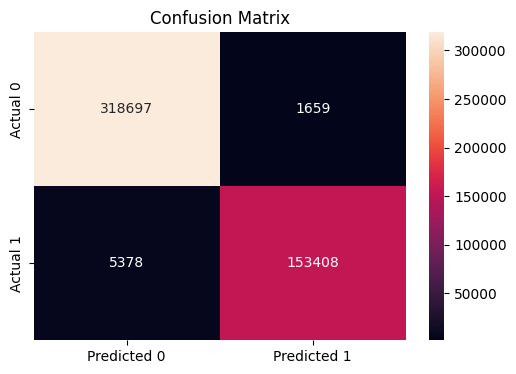

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

matrix = [

[lr_metrics[5], lr_metrics[6]],
[lr_metrics[7], lr_metrics[4]]

]

plt.figure(figsize=(6,4))

sns.heatmap(
matrix,
annot=True,
fmt="d",
xticklabels=["Predicted 0","Predicted 1"],
yticklabels=["Actual 0","Actual 1"]
)

plt.title("Confusion Matrix")

plt.show()

In [15]:
import pandas as pd
import os

# Folder where your CSV files exist
folder_path = "/content/drive/MyDrive/project/tableau"

# Output Excel file
output_file = os.path.join(folder_path, "project_dashboard_data.xlsx")

# List of CSV files to include
csv_files = [
    "class_distribution.csv",
    "confusion_matrix.csv",
    "data_sample.csv",
    "data_split_distribution.csv",
    "feature_importance.csv",
    "final_model_metrics.csv",
    "model_comparison.csv"
]

# Create Excel writer
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:

    for file in csv_files:

        file_path = os.path.join(folder_path, file)

        df = pd.read_csv(file_path)

        sheet_name = file.replace(".csv","")

        df.to_excel(writer, sheet_name=sheet_name, index=False)

print("Excel file created successfully")
print(output_file)

Excel file created successfully
/content/drive/MyDrive/project/tableau/project_dashboard_data.xlsx
